# AI4I 2020 Predictive Maintenance Project

## 1. Imports 

In [ ]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from matplotlib.patches import FancyBboxPatch, FancyArrowPatch


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.base import clone

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, IsolationForest
from sklearn.svm import SVC, OneClassSVM
from sklearn.cluster import DBSCAN, KMeans

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

RANDOM_STATE = 42
TARGET_COLUMN = "Machine failure"
USELESS_COLUMNS = ["UDI", "Product ID"]
FAILURE_TYPE_COLUMNS = ["TWF", "HDF", "PWF", "OSF", "RNF"]

## 2. Dataset Loading

In [ ]:
df = pd.read_csv("/Users/macbook/Desktop/test/AI4I_2020_Pr/Dataset/ai4i2020.csv")
df.head()


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 3. Quick Tour

In [ ]:
print("Dataset shape:", df.shape)
print("\nColumns:")
df.columns.tolist()
print("\nMissing values:")
df.isna().sum()
print("\nDuplicated rows:", df.duplicated().sum())

display(df.info())
display(df.describe())


Dataset shape: (10000, 14)

Columns:

Missing values:

Duplicated rows: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF

None

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


## 4. Pretreatment

In [ ]:
df_clean = df.copy()

df_clean = df_clean.drop_duplicates()

for column in df_clean.columns:
    if df_clean[column].dtype == "object":
        df_clean[column] = df_clean[column].fillna(df_clean[column].mode()[0])
    else:
        df_clean[column] = df_clean[column].fillna(df_clean[column].median())
print("Shape after cleaning:", df_clean.shape)


Shape after cleaning: (10000, 14)


## 5. Exploratory Data Analysis

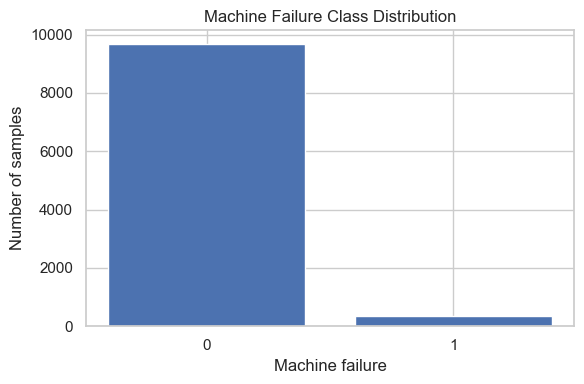

In [ ]:
class_counts = df_clean[TARGET_COLUMN].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.title("Machine Failure Class Distribution")
plt.xlabel("Machine failure")
plt.ylabel("Number of samples")
plt.tight_layout()
plt.show()


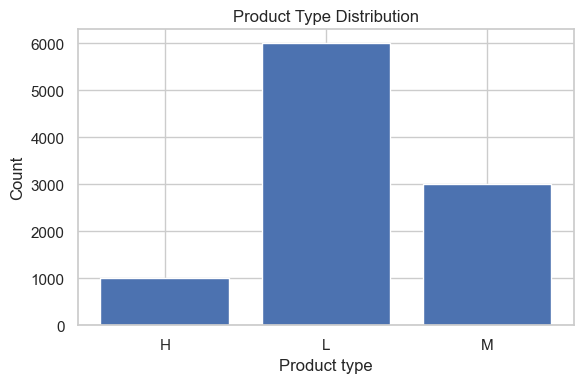

In [ ]:
type_counts = df_clean["Type"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(type_counts.index.astype(str), type_counts.values)
plt.title("Product Type Distribution")
plt.xlabel("Product type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

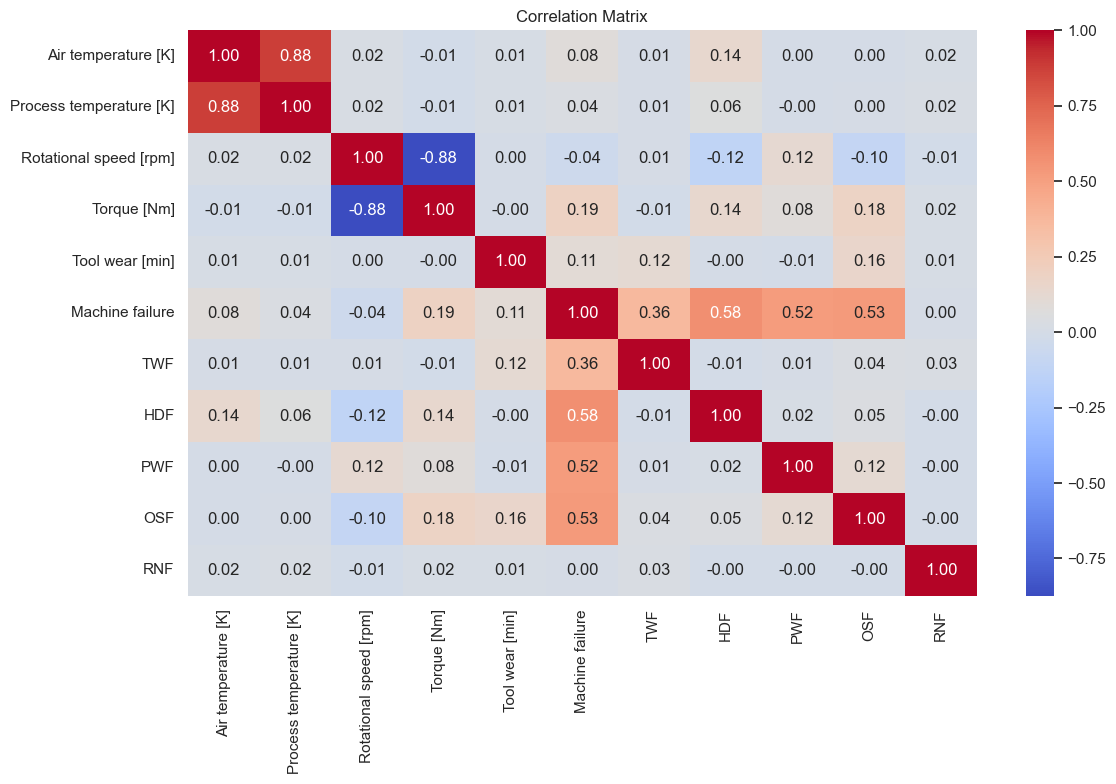

In [ ]:
numeric_df = df_clean.select_dtypes(include="number").drop(columns=USELESS_COLUMNS, errors="ignore")

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


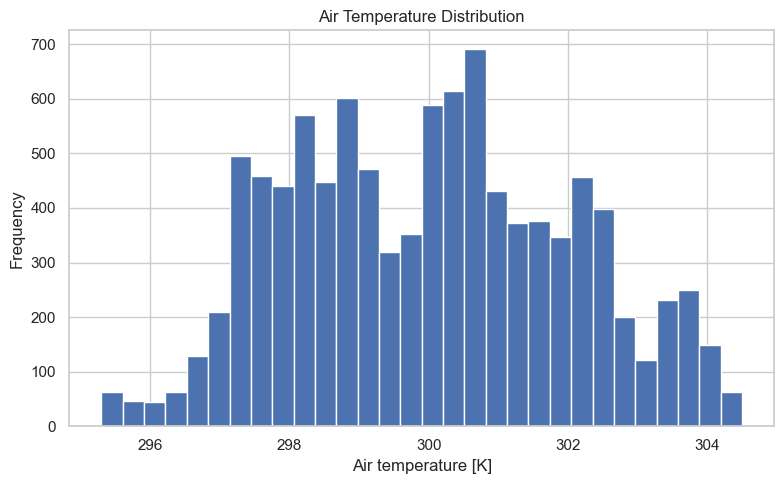

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df_clean["Air temperature [K]"], bins=30)
plt.title("Air Temperature Distribution")
plt.xlabel("Air temperature [K]")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

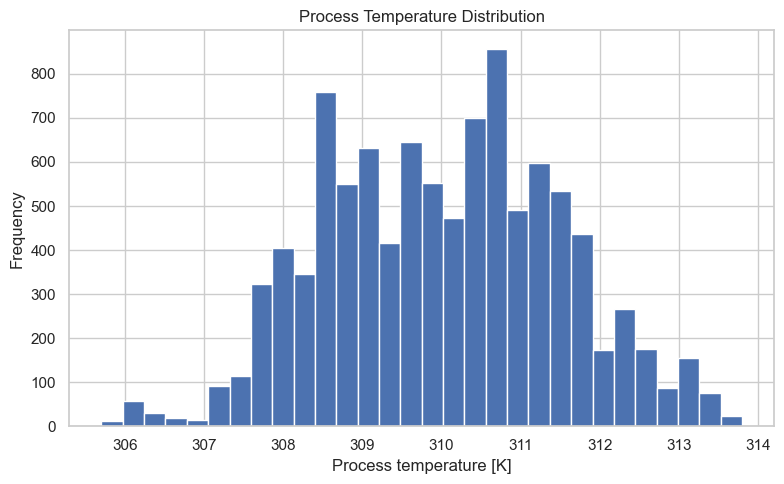

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df_clean["Process temperature [K]"], bins=30)
plt.title("Process Temperature Distribution")
plt.xlabel("Process temperature [K]")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

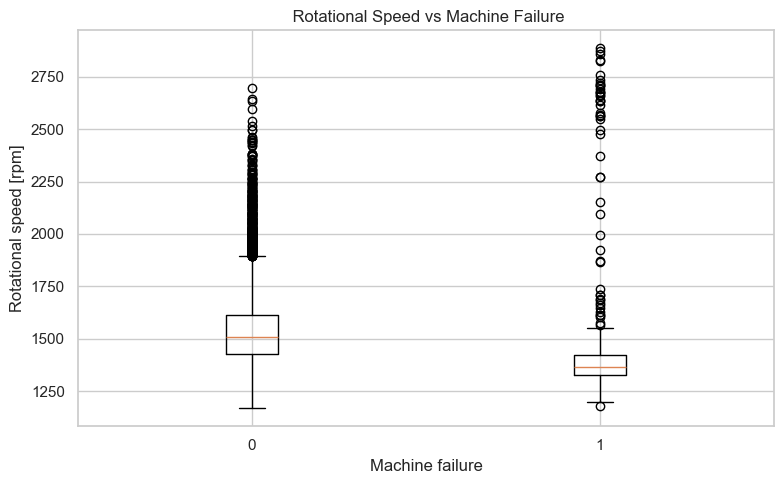

In [ ]:
normal_values = df_clean.loc[df_clean[TARGET_COLUMN] == 0, "Rotational speed [rpm]"]
failure_values = df_clean.loc[df_clean[TARGET_COLUMN] == 1, "Rotational speed [rpm]"]

plt.figure(figsize=(8, 5))
plt.boxplot([normal_values, failure_values], labels=["0", "1"])
plt.title(" Rotational Speed vs Machine Failure")
plt.xlabel("Machine failure")
plt.ylabel("Rotational speed [rpm]")
plt.tight_layout()
plt.show()

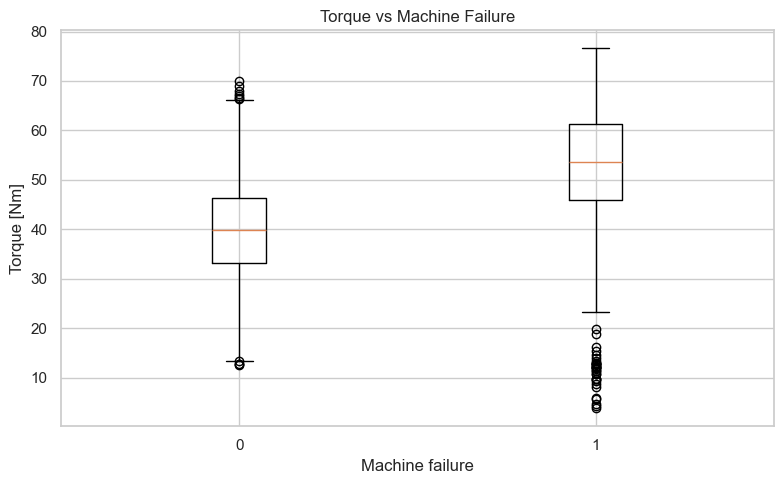

In [ ]:
normal_values = df_clean.loc[df_clean[TARGET_COLUMN] == 0, "Torque [Nm]"]
failure_values = df_clean.loc[df_clean[TARGET_COLUMN] == 1, "Torque [Nm]"]

plt.figure(figsize=(8, 5))
plt.boxplot([normal_values, failure_values], labels=["0", "1"])
plt.title("Torque vs Machine Failure")
plt.xlabel("Machine failure")
plt.ylabel("Torque [Nm]")
plt.tight_layout()
plt.show()

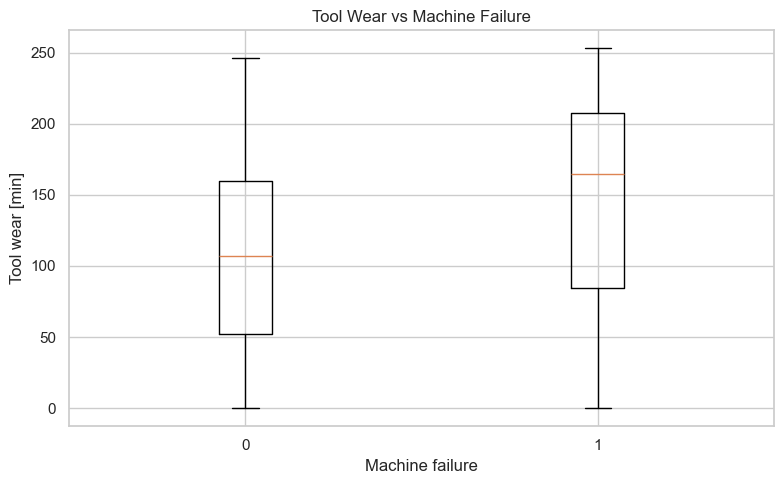

In [ ]:
normal_values = df_clean.loc[df_clean[TARGET_COLUMN] == 0, "Tool wear [min]"]
failure_values = df_clean.loc[df_clean[TARGET_COLUMN] == 1, "Tool wear [min]"]

plt.figure(figsize=(8, 5))
plt.boxplot([normal_values, failure_values], labels=["0", "1"])
plt.title("Tool Wear vs Machine Failure")
plt.xlabel("Machine failure")
plt.ylabel("Tool wear [min]")
plt.tight_layout()
plt.show()

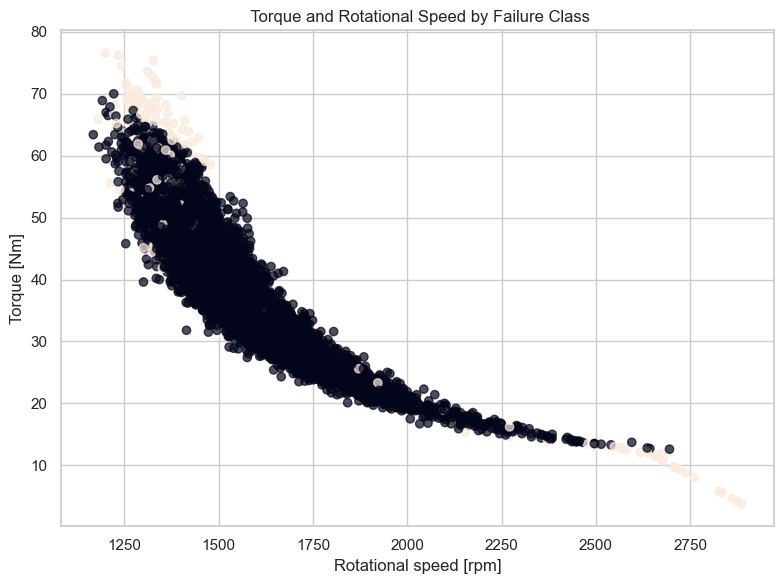

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(
    df_clean["Rotational speed [rpm]"],
    df_clean["Torque [Nm]"],
    c=df_clean[TARGET_COLUMN],
    alpha=0.7,
)
plt.title(" Torque and Rotational Speed by Failure Class")
plt.xlabel("Rotational speed [rpm]")
plt.ylabel("Torque [Nm]")
plt.tight_layout()
plt.show()

## 6. Feature Engineering

In [ ]:
df_features = df_clean.copy()

df_features["Temperature Difference"] = (
    df_features["Process temperature [K]"] - df_features["Air temperature [K]"]
)

df_features["Power"] = (
    df_features["Torque [Nm]"] * df_features["Rotational speed [rpm]"]
)

df_features["Wear Torque Interaction"] = (
    df_features["Tool wear [min]"] * df_features["Torque [Nm]"]
)

df_features["Speed Torque Ratio"] = (
    df_features["Rotational speed [rpm]"] / df_features["Torque [Nm]"].replace(0, np.nan)
).fillna(0)

display(df_features.head())


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Temperature Difference,Power,Wear Torque Interaction,Speed Torque Ratio
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,10.5,66382.8,0.0,36.238318
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,10.5,65190.4,138.9,30.410367
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,10.4,74001.2,247.0,30.323887
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,10.4,56603.5,276.5,36.278481
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,10.5,56320.0,360.0,35.200000


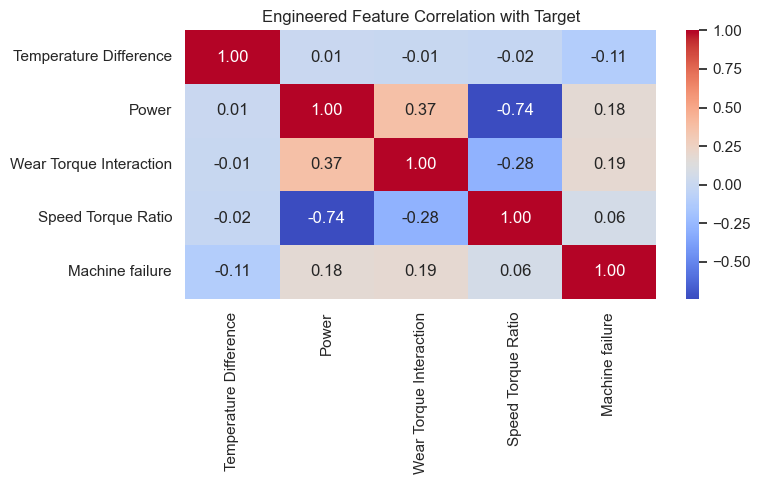

In [ ]:

engineered_columns = ["Temperature Difference", "Power", "Wear Torque Interaction", "Speed Torque Ratio", TARGET_COLUMN]

plt.figure(figsize=(8, 5))
sns.heatmap(df_features[engineered_columns].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Engineered Feature Correlation with Target")
plt.tight_layout()
plt.show()


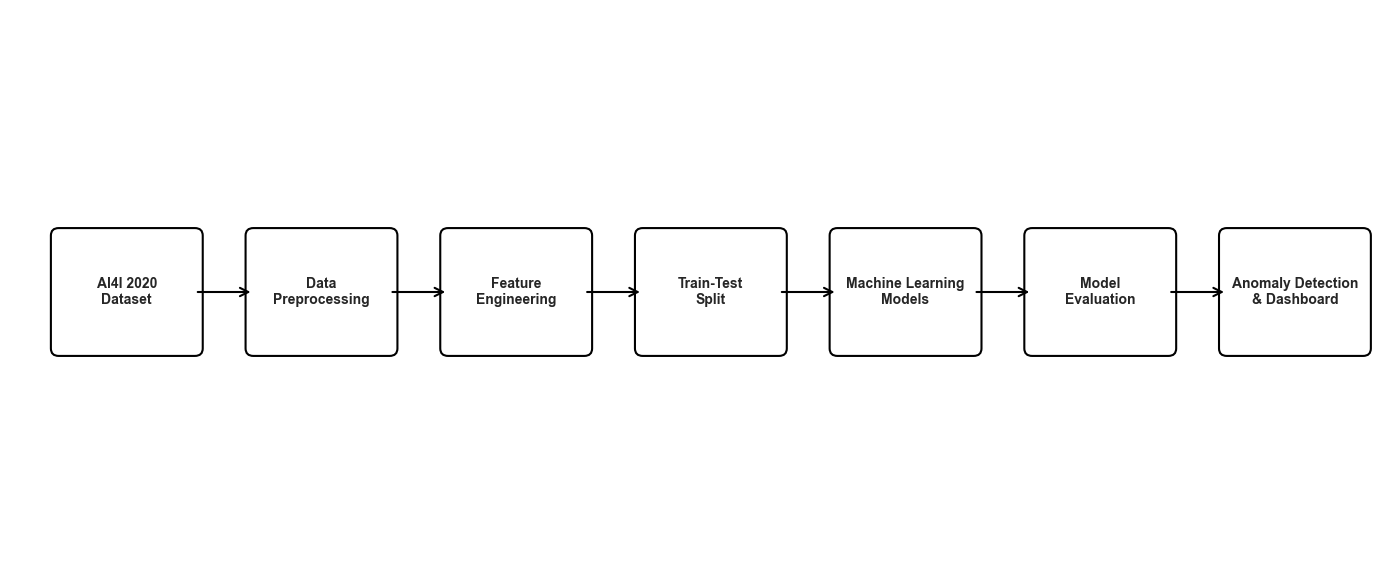

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.set_xlim(0, 14)
ax.set_ylim(0, 6)
ax.axis("off")

steps = [
    ("AI4I 2020\nDataset", 0.5, 3),
    ("Data\nPreprocessing", 2.5, 3),
    ("Feature\nEngineering", 4.5, 3),
    ("Train-Test\nSplit", 6.5, 3),
    ("Machine Learning\nModels", 8.5, 3),
    ("Model\nEvaluation", 10.5, 3),
    ("Anomaly Detection\n& Dashboard", 12.5, 3),
]

for text, x, y in steps:
    box = FancyBboxPatch(
        (x, y - 0.6),
        1.4,
        1.2,
        boxstyle="round,pad=0.08",
        linewidth=1.5,
        facecolor="white",
        edgecolor="black"
    )
    ax.add_patch(box)

    ax.text(
        x + 0.7,
        y,
        text,
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

for i in range(len(steps) - 1):
    x1 = steps[i][1] + 1.4
    y1 = steps[i][2]
    x2 = steps[i + 1][1]
    y2 = steps[i + 1][2]

    arrow = FancyArrowPatch(
        (x1, y1),
        (x2, y2),
        arrowstyle="->",
        mutation_scale=15,
        linewidth=1.5,
        color="black"
    )
    ax.add_patch(arrow)

ax.text(
    7,
    5.2,
    " ",
    ha="center",
    va="center",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## 7. Dimensionality Reduction

In [ ]:

model_df = df_features.drop(columns=USELESS_COLUMNS + FAILURE_TYPE_COLUMNS, errors="ignore")
X = model_df.drop(columns=[TARGET_COLUMN])
y = model_df[TARGET_COLUMN]

categorical_features = X.select_dtypes(include="object").columns.tolist()
numerical_features = X.select_dtypes(exclude="object").columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numerical", StandardScaler(), numerical_features),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

print("Training shape:", X_train_scaled.shape)


Training shape: (8000, 12)


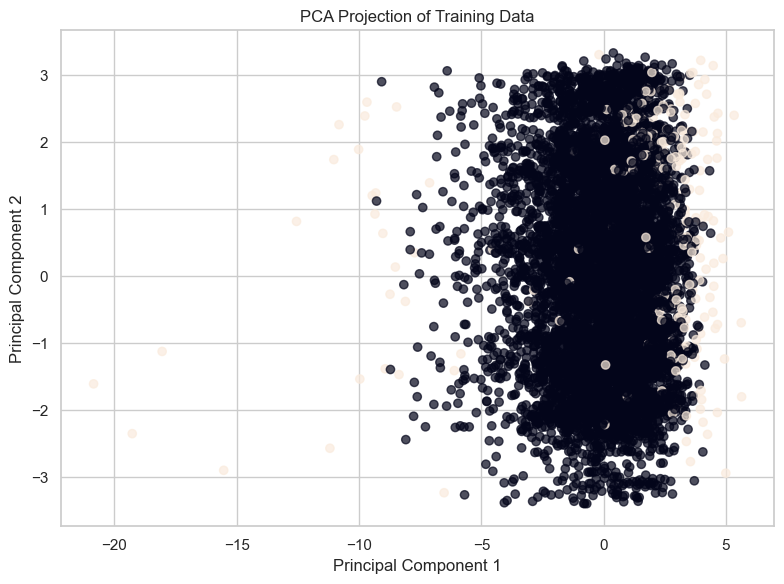

In [ ]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, alpha=0.7)
plt.title("PCA Projection of Training Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.tight_layout()
plt.show()


## 8. Supervised Predictive Maintenance Models

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=150, class_weight="balanced", random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "SVM": SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=RANDOM_STATE),
}

trained_models = {}
results = []

for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", clone(preprocessor)),
        ("model", model),
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    if hasattr(pipeline.named_steps["model"], "predict_proba"):
        y_score = pipeline.predict_proba(X_test)[:, 1]
    elif hasattr(pipeline.named_steps["model"], "decision_function"):
        y_score = pipeline.decision_function(X_test)
    else:
        y_score = None

    results.append({
        "Model": name,
        "Type": "Supervised",
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_score) if y_score is not None and len(np.unique(y_test)) > 1 else np.nan,
        "Confusion Matrix": confusion_matrix(y_test, y_pred).tolist(),
    })
    trained_models[name] = pipeline

results_df = pd.DataFrame(results).sort_values("F1-Score", ascending=False)
display(results_df)

,Model,Type,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Confusion Matrix
2,Gradient Boosting,Supervised,0.9930,1.000000,0.794118,0.885246,0.966200,"[[1932, 0], [14, 54]]"
1,Random Forest,Supervised,0.9900,0.961538,0.735294,0.833333,0.972259,"[[1930, 2], [18, 50]]"
3,SVM,Supervised,0.9235,0.296651,0.911765,0.447653,0.970333,"[[1785, 147], [6, 62]]"
0,Logistic Regression,Supervised,0.8495,0.169972,0.882353,0.285036,0.940636,"[[1639, 293], [8, 60]]"


## 9. Unsupervised Anomaly Detection Models

In [ ]:
anomaly_models = {
    "Isolation Forest": IsolationForest(contamination=0.04, random_state=RANDOM_STATE),
    "One-Class SVM": OneClassSVM(nu=0.04, kernel="rbf", gamma="scale"),
    "DBSCAN": DBSCAN(eps=2.5, min_samples=8),
}

anomaly_results = []
trained_anomaly_models = {}

normal_train_mask = y_train == 0
X_train_normal_scaled = X_train_scaled[normal_train_mask]

for name, model in anomaly_models.items():
    if name == "DBSCAN":
        raw_pred = model.fit_predict(X_test_scaled)
        y_score = None
        trained_anomaly_models[name] = model.fit(X_train_normal_scaled)
    else:
        model.fit(X_train_normal_scaled)
        raw_pred = model.predict(X_test_scaled)
        y_score = -model.decision_function(X_test_scaled)
        trained_anomaly_models[name] = model

    y_pred = np.where(raw_pred == -1, 1, 0)

    anomaly_results.append({
        "Model": name,
        "Type": "Unsupervised/Anomaly",
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_score) if y_score is not None and len(np.unique(y_test)) > 1 else np.nan,
        "Confusion Matrix": confusion_matrix(y_test, y_pred).tolist(),
    })

anomaly_results_df = pd.DataFrame(anomaly_results).sort_values("F1-Score", ascending=False)
combined_results_df = pd.concat([results_df, anomaly_results_df], ignore_index=True).sort_values("F1-Score", ascending=False)

COMPARISON_PATH = Path("../results/model_comparison.csv")
COMPARISON_PATH.parent.mkdir(parents=True, exist_ok=True)

comparison_df = combined_results_df[[
    "Model", "Type", "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC", "Confusion Matrix"
]].copy()
comparison_df.to_csv(COMPARISON_PATH, index=False)

display(anomaly_results_df)
display(comparison_df)
print("Model comparison saved to:", COMPARISON_PATH)


,Model,Type,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Confusion Matrix
1,One-Class SVM,Unsupervised/Anomaly,0.9380,0.266667,0.470588,0.340426,0.873813,"[[1844, 88], [36, 32]]"
0,Isolation Forest,Unsupervised/Anomaly,0.9355,0.198020,0.294118,0.236686,0.830563,"[[1851, 81], [48, 20]]"
2,DBSCAN,Unsupervised/Anomaly,0.9680,0.833333,0.073529,0.135135,NaN,"[[1931, 1], [63, 5]]"


,Model,Type,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Confusion Matrix
0,Gradient Boosting,Supervised,0.9930,1.000000,0.794118,0.885246,0.966200,"[[1932, 0], [14, 54]]"
1,Random Forest,Supervised,0.9900,0.961538,0.735294,0.833333,0.972259,"[[1930, 2], [18, 50]]"
2,SVM,Supervised,0.9235,0.296651,0.911765,0.447653,0.970333,"[[1785, 147], [6, 62]]"
4,One-Class SVM,Unsupervised/Anomaly,0.9380,0.266667,0.470588,0.340426,0.873813,"[[1844, 88], [36, 32]]"
3,Logistic Regression,Supervised,0.8495,0.169972,0.882353,0.285036,0.940636,"[[1639, 293], [8, 60]]"
5,Isolation Forest,Unsupervised/Anomaly,0.9355,0.198020,0.294118,0.236686,0.830563,"[[1851, 81], [48, 20]]"
6,DBSCAN,Unsupervised/Anomaly,0.9680,0.833333,0.073529,0.135135,NaN,"[[1931, 1], [63, 5]]"


Model comparison saved to: ../results/model_comparison.csv


## 10. Evaluation Metrics

<Figure size 1200x600 with 0 Axes>

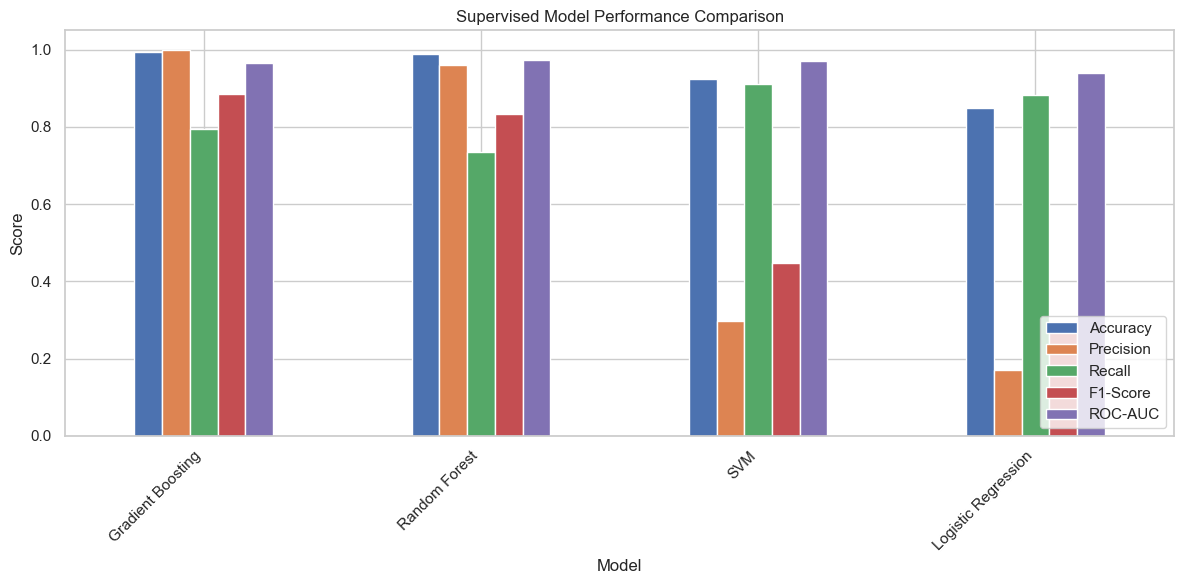

In [ ]:
metric_columns = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
plot_df = results_df.set_index("Model")[metric_columns]

plt.figure(figsize=(12, 6))
plot_df.plot(kind="bar", figsize=(12, 6))
plt.title("Supervised Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=45, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


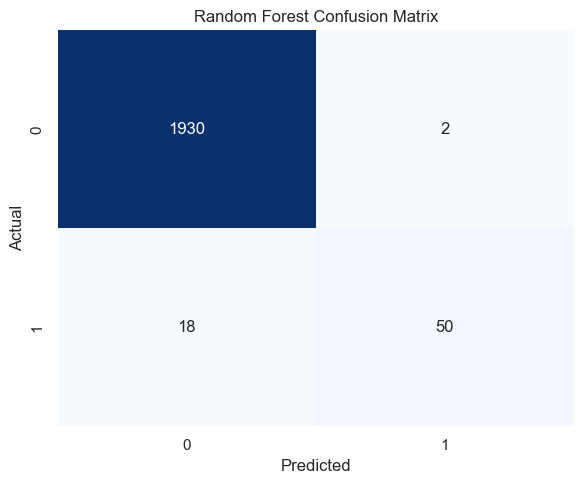

In [ ]:

rf_pred = trained_models["Random Forest"].predict(X_test)
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


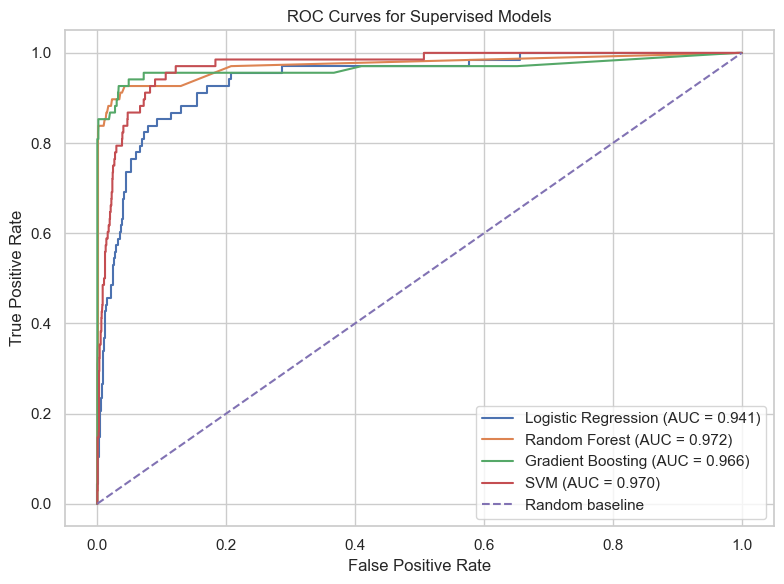

In [ ]:

plt.figure(figsize=(8, 6))

for name, pipeline in trained_models.items():
    if hasattr(pipeline.named_steps["model"], "predict_proba"):
        y_score = pipeline.predict_proba(X_test)[:, 1]
    elif hasattr(pipeline.named_steps["model"], "decision_function"):
        y_score = pipeline.decision_function(X_test)
    else:
        continue

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random baseline")
plt.title("ROC Curves for Supervised Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


<Figure size 1200x600 with 0 Axes>

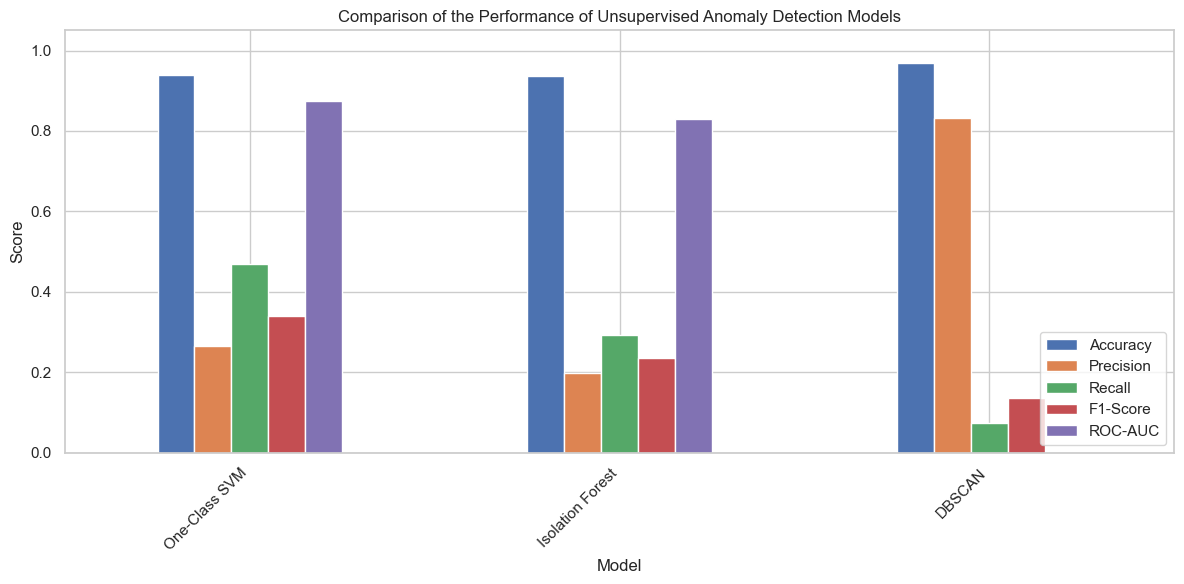

In [ ]:
unsupervised_metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

plot_unsupervised_df = anomaly_results_df.set_index("Model")[unsupervised_metrics]

plt.figure(figsize=(12, 6))
plot_unsupervised_df.plot(kind="bar", figsize=(12, 6))

plt.title("Comparison of the Performance of Unsupervised Anomaly Detection Models")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=45, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

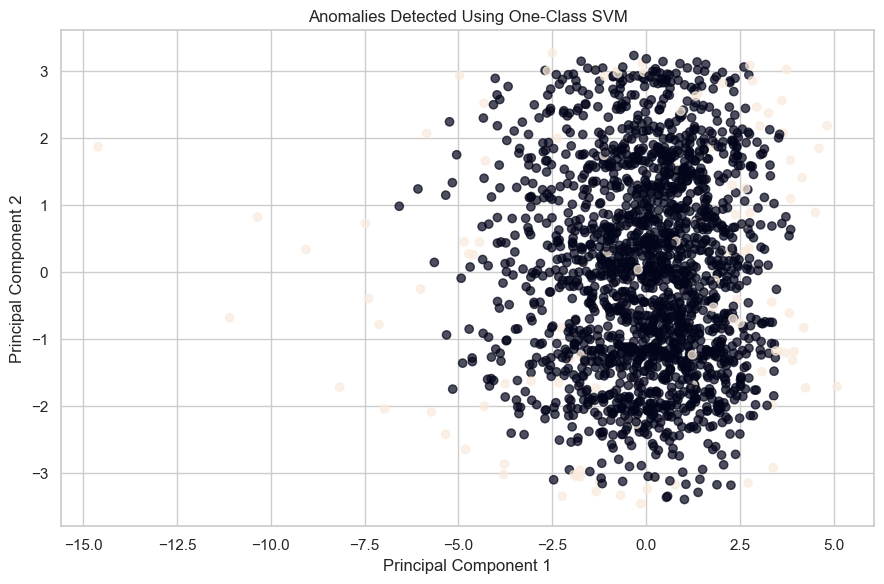

Best unsupervised model: One-Class SVM


In [ ]:
best_unsupervised_model_name = anomaly_results_df.iloc[0]["Model"]
best_unsupervised_model = trained_anomaly_models[best_unsupervised_model_name]

if best_unsupervised_model_name == "DBSCAN":
    raw_pred = best_unsupervised_model.fit_predict(X_test_scaled)
else:
    raw_pred = best_unsupervised_model.predict(X_test_scaled)

y_pred_anomaly = np.where(raw_pred == -1, 1, 0)

pca_anomaly = PCA(n_components=2, random_state=RANDOM_STATE)
X_test_pca = pca_anomaly.fit_transform(X_test_scaled)

plt.figure(figsize=(9, 6))
plt.scatter(
    X_test_pca[:, 0],
    X_test_pca[:, 1],
    c=y_pred_anomaly,
    alpha=0.7
)

plt.title(f"Anomalies Detected Using {best_unsupervised_model_name}")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.tight_layout()
plt.show()

print("Best unsupervised model:", best_unsupervised_model_name)

## 11. Comparative Results

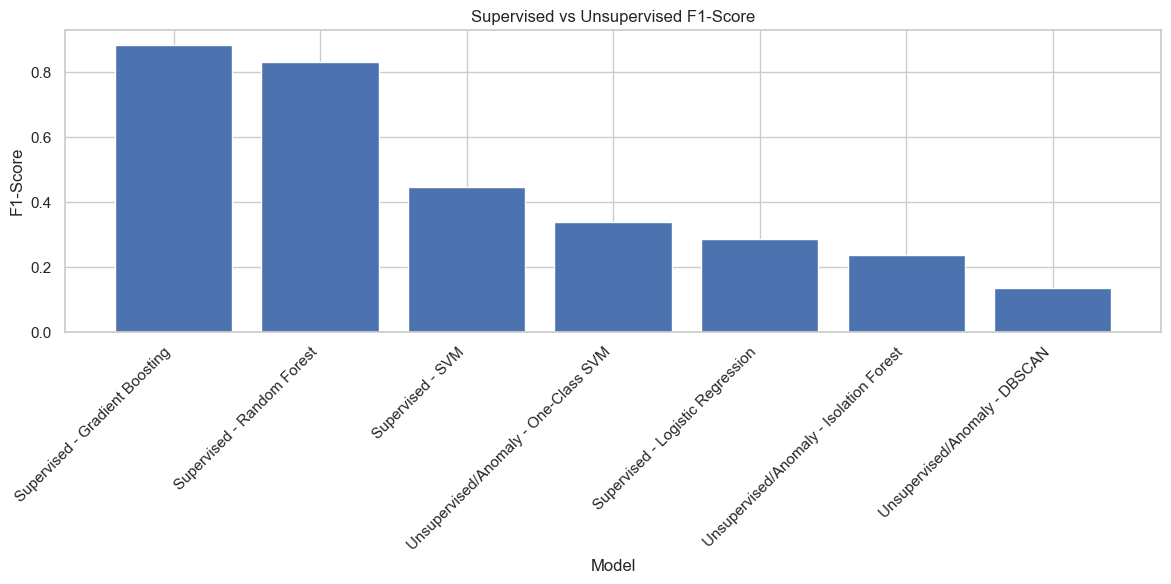

In [ ]:
combined_f1 = combined_results_df[["Model", "Type", "F1-Score"]].copy()
combined_f1["Label"] = combined_f1["Type"] + " - " + combined_f1["Model"]

plt.figure(figsize=(12, 6))
plt.bar(combined_f1["Label"], combined_f1["F1-Score"])
plt.title("Supervised vs Unsupervised F1-Score")
plt.xlabel("Model")
plt.ylabel("F1-Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

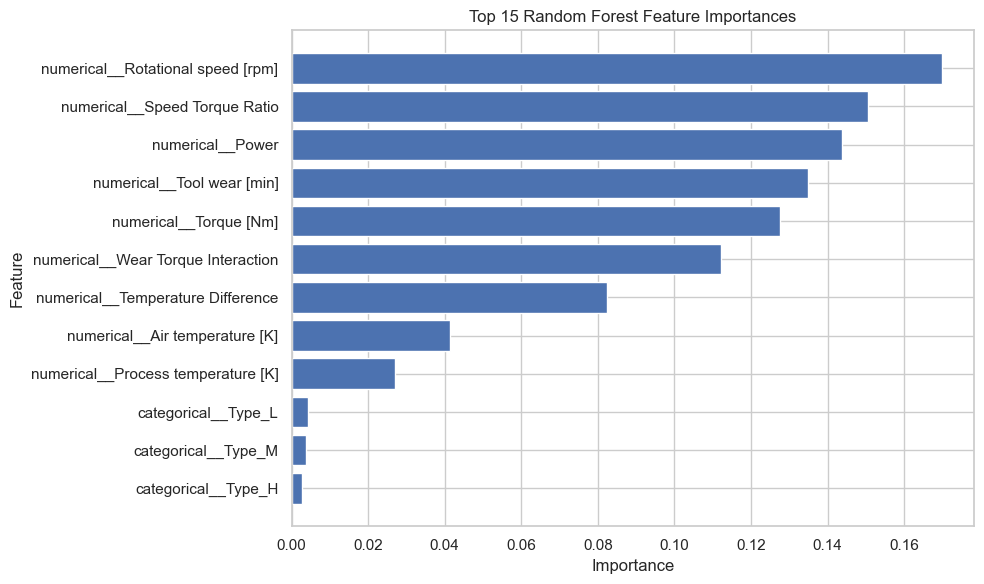

In [ ]:
rf_pipeline = trained_models["Random Forest"]
rf_model = rf_pipeline.named_steps["model"]
rf_preprocessor = rf_pipeline.named_steps["preprocessor"]

feature_names = rf_preprocessor.get_feature_names_out()
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_,
}).sort_values("Importance", ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance["Feature"][::-1], feature_importance["Importance"][::-1])
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 12. Failure Type Analysis

In [ ]:
available_failure_columns = [col for col in FAILURE_TYPE_COLUMNS if col in df_features.columns]
failure_counts = df_features[available_failure_columns].sum().sort_values(ascending=False)
display(failure_counts.to_frame("Count"))


,Count
HDF,115
OSF,98
PWF,95
TWF,46
RNF,19


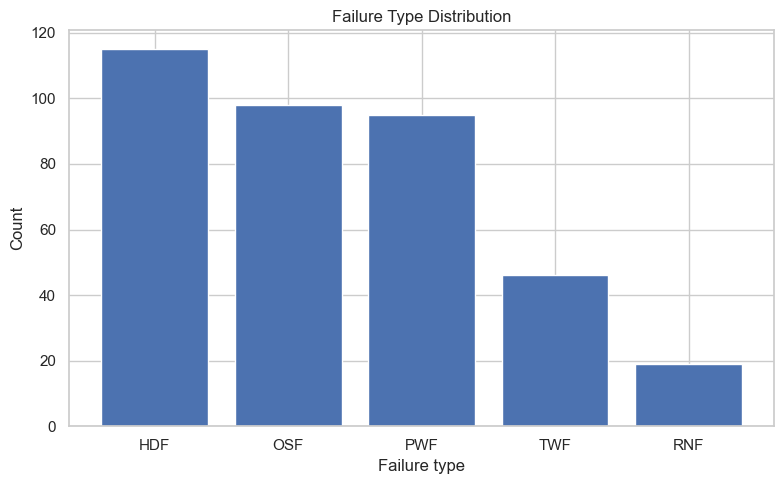

In [ ]:

plt.figure(figsize=(8, 5))
plt.bar(failure_counts.index, failure_counts.values)
plt.title("Failure Type Distribution")
plt.xlabel("Failure type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


## 13. Real-Time Sensor Simulation

In [ ]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

simulation_sample = X_test.head(50).copy()
simulation_predictions = best_model.predict(simulation_sample)

if hasattr(best_model.named_steps["model"], "predict_proba"):
    simulation_probabilities = best_model.predict_proba(simulation_sample)[:, 1]
else:
    simulation_probabilities = simulation_predictions

simulation_df = simulation_sample.copy()
simulation_df["Prediction"] = simulation_predictions
simulation_df["Failure Probability"] = simulation_probabilities

display(simulation_df.head())
print("Best model used for simulation:", best_model_name)


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Temperature Difference,Power,Wear Torque Interaction,Speed Torque Ratio,Prediction,Failure Probability
2997,L,300.5,309.8,1345,62.7,153,9.3,84331.5,9593.1,21.451356,0,0.006179
4871,L,303.7,312.4,1513,40.1,135,8.7,60671.3,5413.5,37.730673,0,0.001268
3858,L,302.5,311.4,1559,37.6,209,8.9,58618.4,7858.4,41.462766,0,0.043692
951,H,295.6,306.3,1509,35.8,60,10.7,54022.2,2148.0,42.150838,0,0.001175
6463,H,300.5,310.0,1358,60.4,102,9.5,82023.2,6160.8,22.483444,0,0.006019


Best model used for simulation: Gradient Boosting
